Final Project DATASCI 151: Lucas An, Tiana Lee, Minjun Jang

Do counties that strongly support a presidential candidate vote similarly in Senate races?

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

pres_county = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
pres_candidate = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
senate_county = pd.read_csv("4-US_Election_2020/senate_county.csv")
senate_candidate = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")

print("President county:", pres_county.shape)
print("President candidate:", pres_candidate.shape)
print("Senate county:", senate_county.shape)
print("Senate candidate:", senate_candidate.shape)

display(pres_county.head())
display(pres_candidate.head())
display(senate_county.head())
display(senate_candidate.head())

President county: (32177, 6)
President candidate: (32177, 6)
Senate county: (3582, 5)
Senate candidate: (14125, 5)


,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True


,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True


,state,county,current_votes,total_votes,percent
0,Delaware,Kent County,84975,87025,100
1,Delaware,New Castle County,279462,287633,100
2,Delaware,Sussex County,126498,129352,100
3,Georgia,Appling County,8187,8341,100
4,Georgia,Atkinson County,3097,3155,100


,state,county,candidate,party,total_votes
0,Delaware,Kent County,Lauren Witzke,REP,38571
1,Delaware,Kent County,Mark Turley,IPD,1553
2,Delaware,Kent County,Nadine Frost,LIB,958
3,Delaware,New Castle County,Lauren Witzke,REP,80081
4,Delaware,New Castle County,Mark Turley,IPD,4277


The datasets 'president_county_candidate.csv' and 'senate_county_candidate.csv' were used to build a county level comparison dataset. Both datasets were filtered to include only Democratic and Republican candidates so that vote shares could be compared across elections. The data were grouped by state, county, and party to calculate total votes for each major party within each county.

After grouping, Democratic and Republican vote totals from the presidential and Senate elections were merged into a single dataset called 'merged'. Each row in this dataset represents one county and includes presidential Democratic and Republican votes, Senate Democratic, and Republican votes, total two party votes, and Democratic vote share for each election. This merged dataset allows direct comparison of how counties voted across the two races.

In [37]:
pres_major = pres_candidate.query("party == 'DEM' or party == 'REP'")

pres_grouped = pres_major.groupby(by = ["state", "county", "party"]).agg(
    votes = ("total_votes", "sum")
).reset_index()

pres_dem = pres_grouped.query("party == 'DEM'")[["state", "county", "votes"]].rename(
    columns = {"votes": "pres_dem_votes"}
)

pres_rep = pres_grouped.query("party == 'REP'")[["state", "county", "votes"]].rename(
    columns = {"votes": "pres_rep_votes"}
)

senate_dem = senate_candidate.query("party == 'DEM'").groupby(by = ["state", "county"]).agg(
    senate_dem_votes = ("total_votes", "sum")
).reset_index()

senate_total = senate_county[["state", "county", "total_votes"]].rename(
    columns = {"total_votes": "senate_total_votes"}
)

merged = pd.merge(left = pres_dem, right = pres_rep, on = ["state", "county"], how = "inner")
merged = pd.merge(left = merged, right = senate_dem, on = ["state", "county"], how = "inner")
merged = pd.merge(left = merged, right = senate_total, on = ["state", "county"], how = "inner")

merged["pres_total_major"] = merged["pres_dem_votes"] + merged["pres_rep_votes"]

merged["pres_dem_share"] = merged["pres_dem_votes"] / merged["pres_total_major"]
merged["senate_dem_share"] = merged["senate_dem_votes"] / merged["senate_total_votes"]
merged = merged.query(
    "0 <= pres_dem_share <= 1 and 0 <= senate_dem_share <= 1"
)
#hey y'all this removes the extremeties we were seeing on the graph

merged["share_difference"] = merged["pres_dem_share"] - merged["senate_dem_share"]

display(merged.head())
print(merged.shape)

,state,county,pres_dem_votes,pres_rep_votes,senate_dem_votes,senate_total_votes,pres_total_major,pres_dem_share,senate_dem_share,share_difference
0,Alabama,Autauga County,7503,19838,8277,27770,27341,0.274423,0.298055,-0.023632
1,Alabama,Baldwin County,24578,83544,28925,109679,108122,0.227317,0.263724,-0.036407
2,Alabama,Barbour County,4816,5622,5021,10518,10438,0.461391,0.477372,-0.015981
3,Alabama,Bibb County,1986,7525,2244,9595,9511,0.208811,0.233872,-0.025061
4,Alabama,Blount County,2640,24711,3290,27588,27351,0.096523,0.119255,-0.022732


(2618, 10)


Dataset Overview

The merged dataset contains county level voting information from the 2020 presidential and Senate elections. Each row represents a county, while columns include Democratic and Republican total votes, total major party votes, Democratic vote shares, and the difference between presidential and Senate Democratic support. This dataset will be used to examine how closely counties voted across the two elections and identify places where voting patterns shifted

In [38]:
print("Rows, Columns:", merged.shape)

display(merged.head())

display(merged[[
    "pres_dem_share",
    "senate_dem_share",
    "share_difference"
]].describe().round(3))

Rows, Columns: (2618, 10)


,state,county,pres_dem_votes,pres_rep_votes,senate_dem_votes,senate_total_votes,pres_total_major,pres_dem_share,senate_dem_share,share_difference
0,Alabama,Autauga County,7503,19838,8277,27770,27341,0.274423,0.298055,-0.023632
1,Alabama,Baldwin County,24578,83544,28925,109679,108122,0.227317,0.263724,-0.036407
2,Alabama,Barbour County,4816,5622,5021,10518,10438,0.461391,0.477372,-0.015981
3,Alabama,Bibb County,1986,7525,2244,9595,9511,0.208811,0.233872,-0.025061
4,Alabama,Blount County,2640,24711,3290,27588,27351,0.096523,0.119255,-0.022732


,pres_dem_share,senate_dem_share,share_difference
count,2618.000,2618.000,2618.000
mean,0.313,0.306,0.006
std,0.126,0.136,0.118
min,0.000,0.000,-0.665
25%,0.212,0.204,-0.022
50%,0.303,0.292,0.007
75%,0.403,0.388,0.041
max,1.000,0.964,0.810


Comparing Presidential and Senate Voting Patterns

To examine whether counties voted similarly across the presidential and Senate elections, we compare Democratic vote share in both races. If counties fall close to a straight diagonal pattern, it suggests voting behavior was consistent across elections. Counties far from that pattern indicate stronger support for one party in one race versus the other.

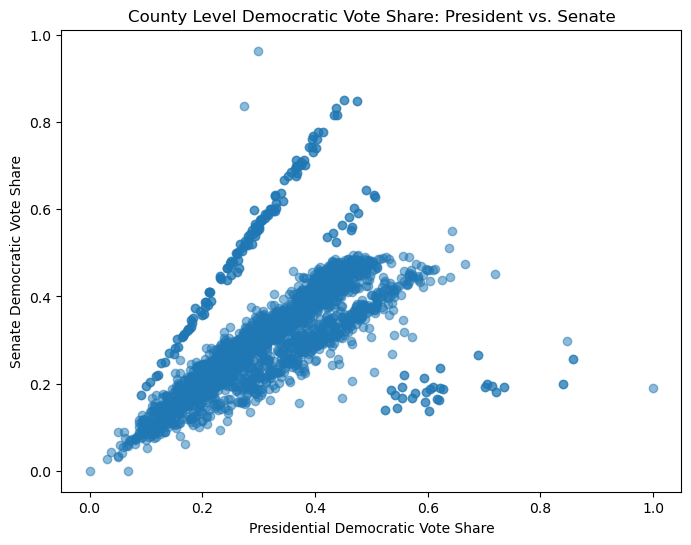

Correlation: 0.596


In [39]:
plt.figure(figsize = (8, 6))

plt.scatter(
    merged["pres_dem_share"],
    merged["senate_dem_share"],
    alpha = 0.5
)

plt.xlabel("Presidential Democratic Vote Share")
plt.ylabel("Senate Democratic Vote Share")
plt.title("County Level Democratic Vote Share: President vs. Senate")
plt.show()

correlation = merged["pres_dem_share"].corr(merged["senate_dem_share"])
print("Correlation:", round(correlation, 3))




